### Repeats

In [1]:
import pandas as pd
from pathlib import Path

REPEAT_CSVS = {
    "base_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_base_atg_repeats.csv",
    "base_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_base_gfp_repeats.csv",
    "ft15_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_ft15_atg_repeats.csv",
    "ft15_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_ft15_gfp_repeats.csv",
    "ft35_atg": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_ft35_atg_repeats.csv",
    "ft35_gfp": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/repeats_csvs/gen_ft35_gfp_repeats.csv",
}

dfs = []
for name, path in REPEAT_CSVS.items():
    t = pd.read_csv(path)
    t["dataset"] = name
    # ensure numeric and drop nans/negatives just in case
    t["longest_len"] = pd.to_numeric(t["longest_len"], errors="coerce")
    t = t.dropna(subset=["longest_len"])
    t = t[t["longest_len"] >= 0]
    dfs.append(t[["plasmid_id","dataset","longest_len"]])

df_rep = pd.concat(dfs, ignore_index=True)
df_rep.head()


,plasmid_id,dataset,longest_len
0,base_generated_000,base_atg,31
1,base_generated_001,base_atg,22
2,base_generated_002,base_atg,32
3,base_generated_003,base_atg,13
4,base_generated_004,base_atg,24


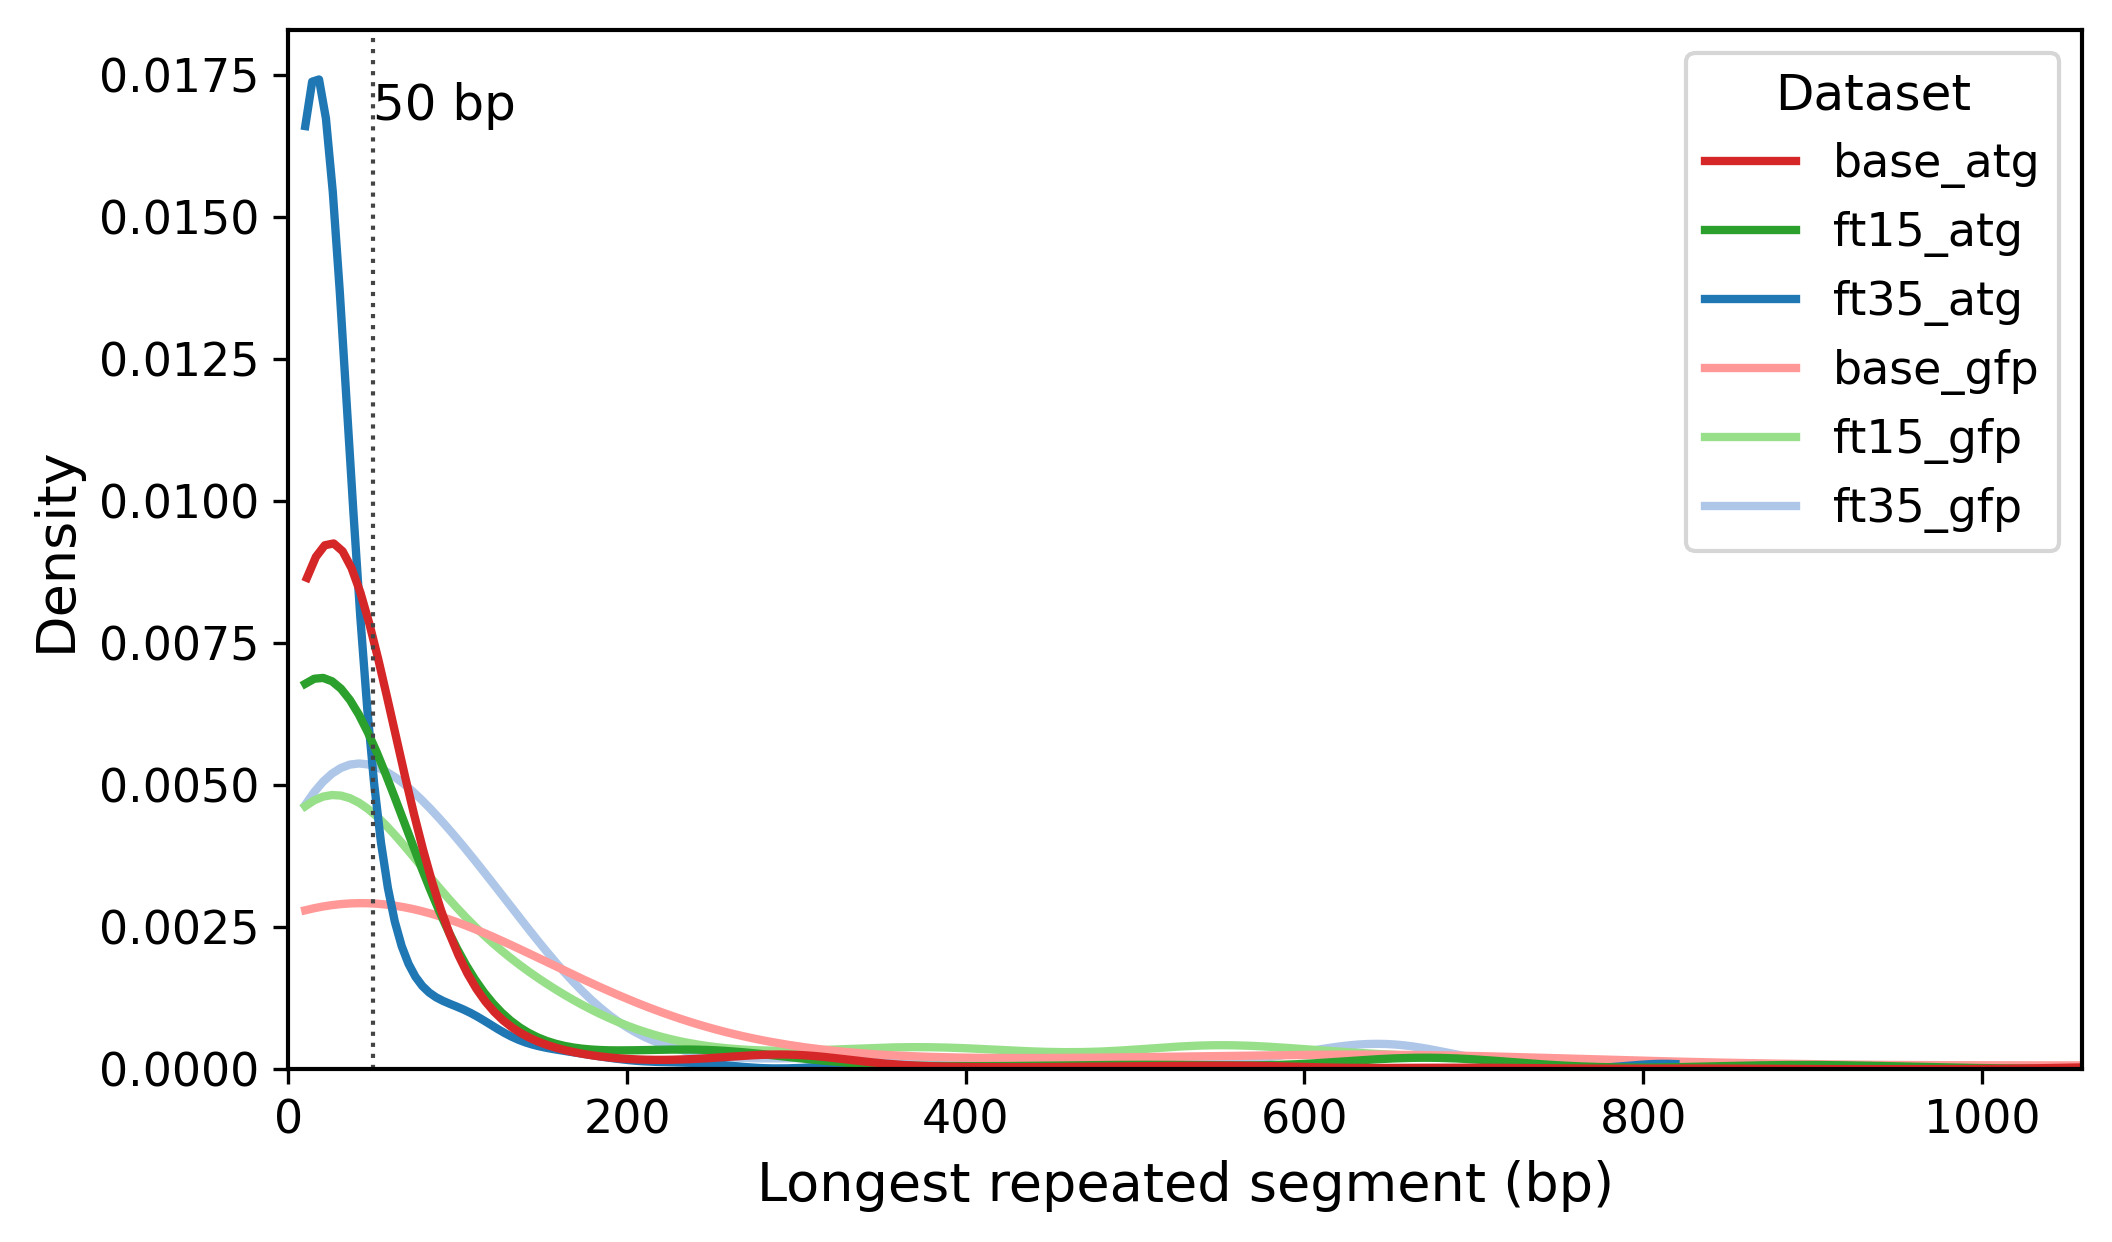

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# House style
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

# Fixed palette (ATG = strong hues; GFP = lighter tints of same hue)
palette = {
    "base_atg": "#d62728",  # red
    "ft15_atg": "#2ca02c",  # green
    "ft35_atg": "#1f77b4",  # blue
    "base_gfp": "#ff9896",  # light red
    "ft15_gfp": "#98df8a",  # light green
    "ft35_gfp": "#aec7e8",  # light blue
}
order = ["base_atg","ft15_atg","ft35_atg","base_gfp","ft15_gfp","ft35_gfp"]

# sensible x-limit based on data (cap to avoid a super long tail)
xmax = float(np.percentile(df_rep["longest_len"], 99))  # 99th percentile
xmax = max(60, min(xmax, 2000))  # keep at least 60bp, cap at 2kb for readability

fig, ax = plt.subplots(figsize=(7.2, 4.3))
sns.kdeplot(
    data=df_rep,
    x="longest_len",
    hue="dataset",
    hue_order=order,
    palette=palette,
    common_norm=False,
    linewidth=2,
    clip=(0, xmax),
    cut=0,
    ax=ax,
)

# 50 bp reference line (filter threshold you’ve used elsewhere)
ax.axvline(50, linestyle=":", color="#444444", linewidth=1)
ax.text(50, ax.get_ylim()[1]*0.95, "50 bp", ha="left", va="top")

ax.set_xlabel("Longest repeated segment (bp)")
ax.set_ylabel("Density")
ax.set_xlim(0, xmax)

# Explicit legend keyed to our palette & order (stable ordering)
handles = [Line2D([0],[0], color=palette[name], lw=2) for name in order]
ax.legend(handles, order, title="Dataset", loc="upper right", frameon=True)

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/repeat_len_density.pdf", bbox_inches="tight")
plt.show()


### QC Filter

In [1]:
import pandas as pd
from pathlib import Path

PASS_FILES = {
    ("base", "ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/baseatgpass_1ori2arg.csv",
    ("base", "GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/basegfppass_1ori2arg.csv",
    ("ft15", "ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15atgpass_1ori2arg.csv",
    ("ft15", "GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15gfppass_1ori2arg.csv",
    ("ft35", "ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35atgpass_1ori2arg.csv",
    ("ft35", "GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35gfppass_1ori2arg.csv",
}

records = []
for (model, sample), path in PASS_FILES.items():
    try:
        n_pass = len(pd.read_csv(path))
    except pd.errors.EmptyDataError:
        n_pass = 0
    pct_pass = round((n_pass / 1000) * 100, 2)
    records.append({
        "model": model,
        "sample": sample,
        "% passed realism": pct_pass
    })

summary_df = pd.DataFrame(records)

# Order nicely
cat_model = pd.Categorical(summary_df["model"], categories=["base","ft15","ft35"], ordered=True)
cat_sample = pd.Categorical(summary_df["sample"], categories=["ATG","GFP"], ordered=True)
summary_df = summary_df.assign(model=cat_model, sample=cat_sample).sort_values(["sample","model"]).reset_index(drop=True)

display(summary_df)

# Save
OUTDIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures")
out_csv = OUTDIR / "realism_pass_rate_summary.csv"
summary_df.to_csv(out_csv, index=False)
print(f"Saved summary → {out_csv}")


,model,sample,% passed realism
0,base,ATG,18.8
1,ft15,ATG,28.2
2,ft35,ATG,0.1
3,base,GFP,25.7
4,ft15,GFP,22.1
5,ft35,GFP,11.2


Saved summary → /cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/realism_pass_rate_summary.csv


In [2]:
import pandas as pd
from pathlib import Path

FAIL_FILES = {
    ("base","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/baseatgfail_1ori2arg.csv",
    ("base","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/basegfpfail_1ori2arg.csv",
    ("ft15","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15atgfail_1ori2arg.csv",
    ("ft15","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15gfpfail_1ori2arg.csv",
    ("ft35","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35atgfail_1ori2arg.csv",
    ("ft35","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35gfpfail_1ori2arg.csv",
}

PASS_FILES = {
    ("base","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/baseatgpass_1ori2arg.csv",
    ("base","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/basegfppass_1ori2arg.csv",
    ("ft15","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15atgpass_1ori2arg.csv",
    ("ft15","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft15gfppass_1ori2arg.csv",
    ("ft35","ATG"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35atgpass_1ori2arg.csv",
    ("ft35","GFP"): "/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_bio/ft35gfppass_1ori2arg.csv",
}

# mapping detailed → simplified
MAP_REASONS = {
    "ARG low-threshold count 0 outside [1,2]": "No ARG",
    "ARG low-threshold count 3 outside [1,2]": "Too many ARG",
    "ARG low-threshold count 4 outside [1,2]": "Too many ARG",
    "No ORI/ARG detected": "No ORI + ARG",
    "ORI low-threshold count 0 outside [1,1]": "No ORI",
    "ORI low-threshold count 2 outside [1,1]": "Too many ORI",
    "ORI low-threshold count 3 outside [1,1]": "Too many ORI",
    "ORI strict threshold not met (ID≥95.0, Cov≥95.0)": "No ORI",
    "repeat ≥ 50": "repeat ≥ 50",
}

fail_records = []
for (model,sample), path in FAIL_FILES.items():
    # count passes to infer silent fails later
    try:
        n_pass = len(pd.read_csv(PASS_FILES[(model,sample)]))
    except pd.errors.EmptyDataError:
        n_pass = 0
    
    try:
        df_fail = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        df_fail = pd.DataFrame(columns=["reason failed"])
    
    # split multiple reasons separated by semicolon
    for reasons in df_fail["reason failed"].dropna():
        for r in str(reasons).split(";"):
            r = r.strip()
            simp = MAP_REASONS.get(r, r)  # fallback = keep original
            fail_records.append({
                "model": model,
                "sample": sample,
                "reason": simp
            })
    
    # add silent fails if pass+fail < 1000
    n_fail = len(df_fail)
    total_rows = n_pass + n_fail
    if total_rows < 1000:
        missing = 1000 - total_rows
        for _ in range(missing):
            fail_records.append({
                "model": model,
                "sample": sample,
                "reason": "No ORI + ARG"
            })

df_fail = pd.DataFrame(fail_records)

# aggregate counts
df_fail_summary = (
    df_fail.groupby(["model","sample","reason"])
           .size().reset_index(name="count")
)

# convert to % of 1000
df_fail_summary["pct_of_total"] = (df_fail_summary["count"] / 1000) * 100

display(df_fail_summary.sort_values(["sample","model","reason"]))


,model,sample,reason,count,pct_of_total
0,base,ATG,No ARG,58,5.8
1,base,ATG,No ORI,95,9.5
2,base,ATG,No ORI + ARG,606,60.6
3,base,ATG,Too many ORI,17,1.7
4,base,ATG,repeat ≥ 50,104,10.4
10,ft15,ATG,No ARG,140,14.0
11,ft15,ATG,No ORI,204,20.4
12,ft15,ATG,No ORI + ARG,327,32.7
13,ft15,ATG,Too many ARG,1,0.1
14,ft15,ATG,Too many ORI,23,2.3


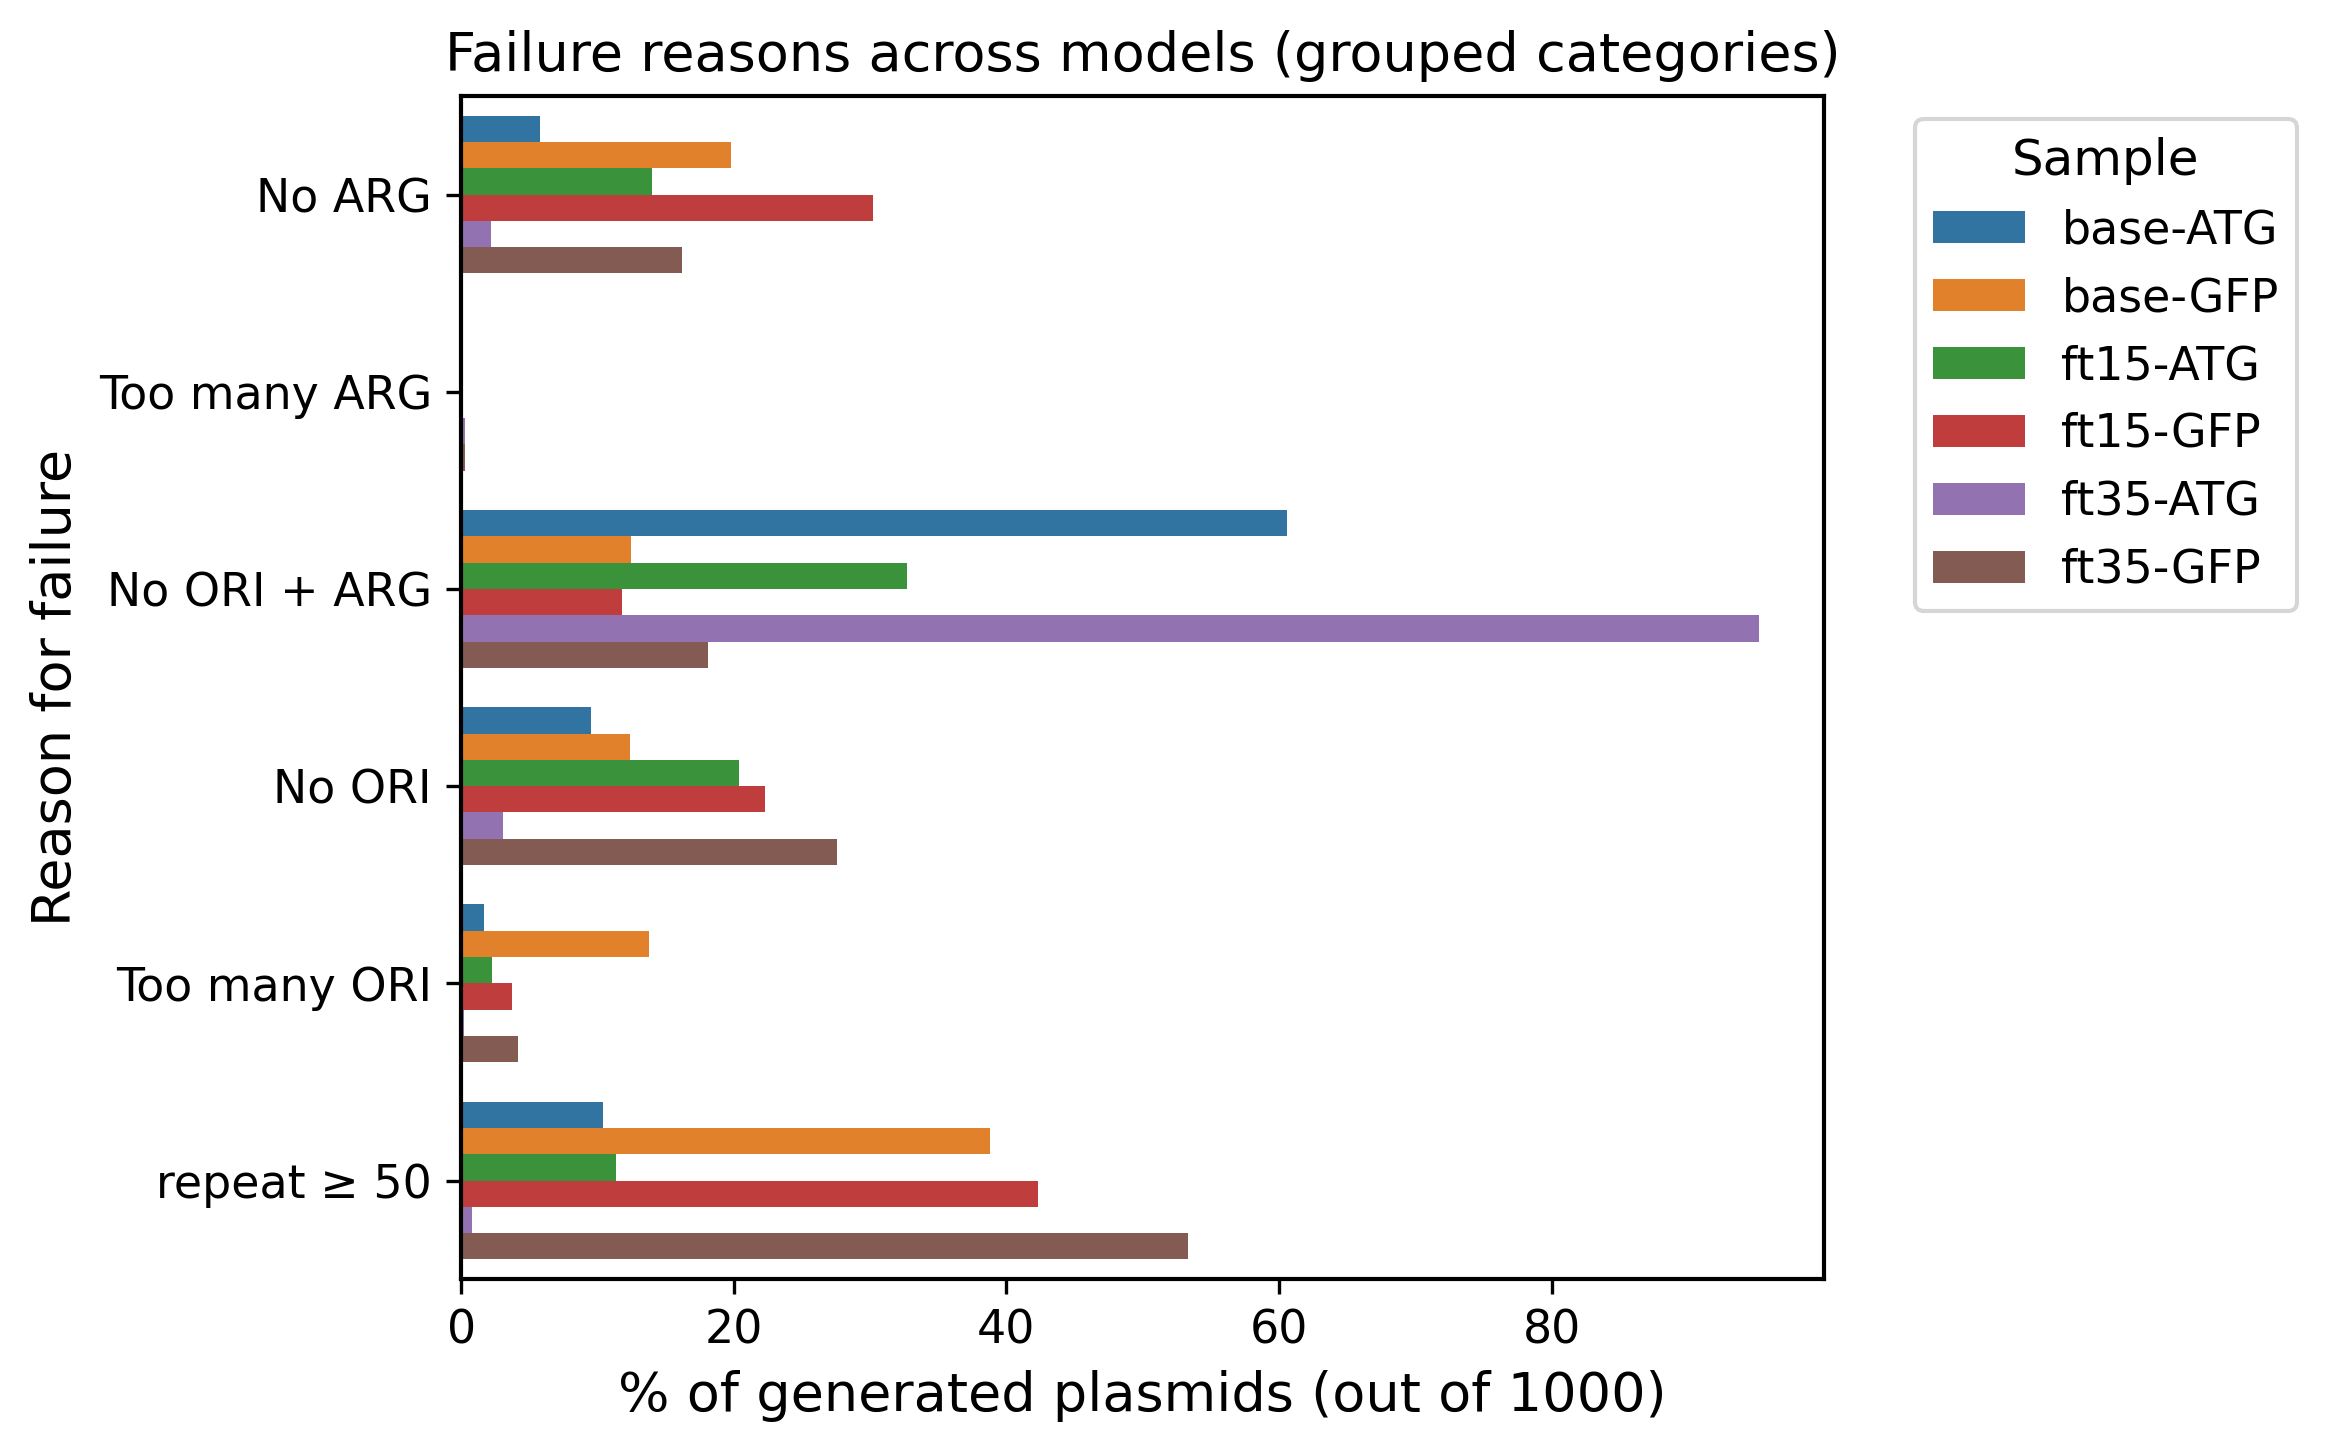

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# combine model+sample label
df_fail_summary["dataset"] = df_fail_summary["model"].astype(str) + "-" + df_fail_summary["sample"].astype(str)

# consistent ordering
reason_order = ["No ARG","Too many ARG","No ORI + ARG","No ORI","Too many ORI","repeat ≥ 50"]
dataset_order = sorted(df_fail_summary["dataset"].unique())

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_fail_summary,
    y="reason", x="pct_of_total",
    hue="dataset", hue_order=dataset_order,
    order=reason_order,
    dodge=True, ax=ax
)

ax.set_xlabel("% of generated plasmids (out of 1000)")
ax.set_ylabel("Reason for failure")
ax.set_title("Failure reasons across models (grouped categories)")
ax.legend(title="Sample", bbox_to_anchor=(1.05,1), loc="upper left", frameon=True)

fig.tight_layout()
fig.savefig("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures/fail_reasons_grouped_clean.pdf", bbox_inches="tight")
plt.show()
